In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 5000

track_temp = np.random.normal(30,5,n)
fuel_load = np.random.uniform(5,100,n)
tire_wear = np.random.uniform(0,100,n)
downforce = np.random.uniform(1,10,n)
aggression = np.random.randint(1,11,n)

track_type = np.random.choice(['Street','Circuit','High_speed'],n)

In [2]:
# Base lap time
lap_time = (90+0.03*fuel_load+0.05*tire_wear-0.8*aggression-0.5*downforce+0.1*(track_temp-30))

In [ ]:
#Track adjustments

lap_time +=np.where(track_type == 'Street',5,0)
lap_time +=np.where(track_type == 'High_speed',-3,0)

In [ ]:
#Add noise

lap_time += np.random.normal(0,1.5,n)

In [3]:
#Create dataframe

df = pd.DataFrame({'Track_temp':track_temp,'FuelLoad':fuel_load,'TireWear':tire_wear,'Downforce':downforce,'Aggression':aggression,'TrackType':track_type,'LapTime':lap_time})
df.head()

,Track_temp,FuelLoad,TireWear,Downforce,Aggression,TrackType,LapTime
0,32.483571,20.982475,31.265631,4.102058,9,Circuit,83.190084
1,29.308678,23.043801,17.823310,4.149357,2,Street,87.838669
2,33.238443,48.767656,85.918220,5.887113,6,High_speed,88.339229
3,37.615149,32.196587,40.352277,4.451517,8,High_speed,85.119268
4,28.829233,28.508983,39.854371,1.012832,3,High_speed,89.824496


In [6]:
#Encode Track Type
df = pd.get_dummies(df,columns=['TrackType'])
df.head()

,Track_temp,FuelLoad,TireWear,Downforce,Aggression,LapTime,TrackType_Circuit,TrackType_High_speed,TrackType_Street
0,32.483571,20.982475,31.265631,4.102058,9,83.190084,True,False,False
1,29.308678,23.043801,17.823310,4.149357,2,87.838669,False,False,True
2,33.238443,48.767656,85.918220,5.887113,6,88.339229,False,True,False
3,37.615149,32.196587,40.352277,4.451517,8,85.119268,False,True,False
4,28.829233,28.508983,39.854371,1.012832,3,89.824496,False,True,False


In [8]:
# Split Data
x = df.drop('LapTime', axis = 1)
y = df['LapTime']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state=42)

In [9]:
#Train Baseline model

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [10]:
#Evaluate model

from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE",rmse)

RMSE 1.3216858887502009e-14


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [13]:
#Evaluate

y_pred_rf = rf_model.predict(x_test)
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))
print("Random Forest RMSE",rmse_rf)


Random Forest RMSE 0.4584945035705461


In [14]:
#Check overfitting

train_pred_rf = rf_model.predict(x_train)
rmse_train_rf= np.sqrt(mean_squared_error(y_train,train_pred_rf))
print("Train RMSE:", rmse_train_rf)
print("Test RMSE:",rmse_rf)

Train RMSE: 0.17366586140752527
Test RMSE: 0.4584945035705461


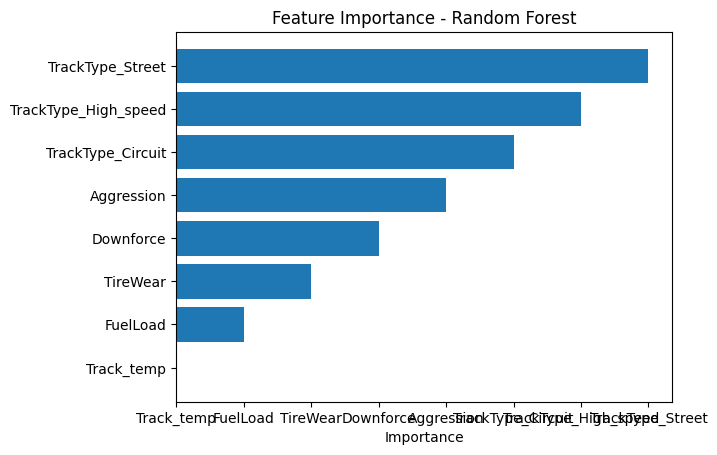

In [16]:
# Feature importance

import matplotlib.pyplot as plt
features = x.columns
importances = x.columns
plt.figure()
plt.barh(features,importances)
plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.show()

In [17]:
#Model cooefficients from linear regression

coefficients =pd.DataFrame({'Feature':x.columns,'Coefficient':model.coef_})
coefficients.sort_values(by='Coefficient',ascending=False)

,Feature,Coefficient
0,Track_temp,1.000000e-01
2,TireWear,5.000000e-02
1,FuelLoad,3.000000e-02
7,TrackType_Street,1.180479e-15
6,TrackType_High_speed,4.048953e-16
5,TrackType_Circuit,-1.395585e-15
3,Downforce,-5.000000e-01
4,Aggression,-8.000000e-01


In [33]:
# Deploying the model
def predict_lap_time(track_temp, fuel_load, tire_wear, downforce, aggression, track_type):

    import pandas as pd

    input_df = pd.DataFrame({
        'Track_temp': [track_temp],
        'FuelLoad': [fuel_load],
        'TireWear': [tire_wear],
        'Downforce': [downforce],
        'Aggression': [aggression],
        'TrackType_Circuit': [1 if track_type == 'Circuit' else 0],
        'TrackType_High_speed': [1 if track_type == 'High_Speed' else 0],
        'TrackType_Street': [1 if track_type == 'Street' else 0]
    })
    # Force correct column order

    input_df = input_df[x.columns]
    return rf_model.predict(input_df)[0]

In [34]:
#Test

predict_lap_time(track_temp =32,fuel_load =80,tire_wear=60,downforce=5,aggression=6,track_type='Street')

np.float64(87.96194801677437)

In [ ]:
print(x.columns)